In [1]:
%load_ext skip_cell
%reload_ext skip_cell

In [2]:
THREE_P_MAN = {
    "RLRRLR": [1,  "RLR", "RLR"],
    "LRLLRL": [2,  "LRL", "LRL"],
    "RLRRSR": [3,  "RLR", "RSR"],
    "RLRRSL": [4,  "RLR", "RSL"],
    "LRLLSL": [5,  "LRL", "LSL"],
    "LRLLSR": [6,  "LRL", "LSR"],
    "RSRRLR": [7,  "RSR", "RLR"],
    "LSRRLR": [8,  "LSR", "RLR"],
    "RSLLRL": [9,  "RSL", "LRL"],
    "LSLLRL": [10, "LSL", "LRL"],
    "RSRRSR": [11, "RSR", "RSR"],
    "LSRRSR": [12, "LSR", "RSR"],
    "RSRRSL": [13, "RSR", "RSL"],
    "LSRRSL": [14, "LSR", "RSL"],
    "LSLLSL": [15, "LSL", "LSL"],
    "RSLLSL": [16, "RSL", "LSL"],
    "LSLLSR": [17, "LSL", "LSR"],
    "RSLLSR": [18, "RSL", "LSR"]
}

THREE_P_MAN_ID = ["RLRRLR", "LRLLRL", "RLRRSR", "RLRRSL", "LRLLSL", "LRLLSR", "RSRRLR", "LSRRLR", "RSLLRL", "LSLLRL", "RSRRSR", "LSRRSR", "RSRRSL", "LSRRSL", "LSLLSL", "RSLLSL", "LSLLSR", "RSLLSR"]


In [3]:
from math import pi, cos, sin, radians, degrees

kmax = 1

theta_i = radians(0)
theta_f = radians(180)
alpha_m = radians(45)
alpha_f = radians(90)

pi_c = (1, 0, theta_i)
pm_c = (cos(alpha_m), sin(alpha_m), 0)
pf_c = (cos(alpha_f), sin(alpha_f), theta_f)

TENSORFLOW = True
SKLEARN = False

assert TENSORFLOW ^ SKLEARN, "Choose one and only one library"

## Import the needed libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Read the dataset and split it into train, val and test

In [5]:
data = pd.read_csv('/home/enrico/Projects/mpdp/3PDS_Circle32_1_1_1.csv', sep='\s+')

features = ['kmax', 'theta_i', 'theta_f', 'alpha_m', 'alpha_f']
target = ['th_m', 'id_man_comb']

X = data[features].values
y = data[target].values

# Split the dataset into training (60%), validation (20%), and test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Multi-modal Tensorflow

In [6]:
%%run_if $TENSORFLOW
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


2024-11-07 08:51:10.153822: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-07 08:51:10.386111: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-07 08:51:11.040949: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available:  1


2024-11-07 08:51:11.523309: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-07 08:51:11.610198: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-07 08:51:11.610475: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [70]:
%%run_if $TENSORFLOW

from datetime import datetime
import time, itertools


def predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler = None):
    input_data = np.array([[kmax, theta_i, theta_f, alpha_m, alpha_f]])
    if scaler:
        input_data = scaler.transform(input_data)

    [[th, id]] = model.predict(input_data)
    
    print(th, id)
    return (th, id)

# Build the neural network model
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dense(1024, activation='relu'),
#     Dense(32, activation='relu'),
#     Dense(2)  # Output layer with 2 outputs for multi-output regression
# ])
# model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

num_layers = range(3,6)
num_neurons = [32, 64, 128, 1024, 4096]

with open('results.txt', 'w') as f:
    f.write('n_layers,n_neurons,test_loss,pred_th,pred_man,neurons\n')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# Given the number of layers, test all combinations
for n_layers in num_layers:
    combinations = itertools.product(num_neurons, repeat=n_layers)
    
    for neurons in combinations:
        print(f'layers: {n_layers}, neurons: {neurons}')
        model = Sequential()
        model.add(Dense(neurons[0], activation='relu', input_shape=(X_train.shape[1],)))
        for n_neurons in neurons[1:-1]:
            model.add(Dense(n_neurons, activation='relu'))
        model.add(Dense(2))

        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

        t = datetime.now()
        model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, verbose=1)
        train_time = (datetime.now() - t)/1000.0

        test_loss = model.evaluate(X_test, y_test)
        # print(f'Test Mean Squared Error: {test_loss}') 

        t = datetime.now()
        pred, man = predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler)
        pred_time = (datetime.now() - t)/1000.0
        # print(f"elapsed {pred_time}")
        with open('results.txt', 'a') as f:
            if pred is not None and man is not None:
            # print(f'The angle of the middle point is: {degrees(pred)}, {pred}')
            # print(f'The angle of the middle point is: {THREE_P_MAN_ID[int(man)-1]}')
                f.write(f'{n_layers},{n_neurons},{test_loss},{pred},{man},{pred_time},{train_time},{neurons}\n')
            else:
                f.write(f'{n_layers},{n_neurons},{test_loss},None,None,{pred_time},{train_time},{neurons}\n')




layers: 3, neurons: (32, 32, 32)
layers: 3, neurons: (32, 32, 64)
layers: 3, neurons: (32, 32, 128)
layers: 3, neurons: (32, 32, 1024)
layers: 3, neurons: (32, 32, 4096)
layers: 3, neurons: (32, 64, 32)
layers: 3, neurons: (32, 64, 64)
layers: 3, neurons: (32, 64, 128)
layers: 3, neurons: (32, 64, 1024)
layers: 3, neurons: (32, 64, 4096)
layers: 3, neurons: (32, 128, 32)
layers: 3, neurons: (32, 128, 64)
layers: 3, neurons: (32, 128, 128)
layers: 3, neurons: (32, 128, 1024)
layers: 3, neurons: (32, 128, 4096)
layers: 3, neurons: (32, 1024, 32)
layers: 3, neurons: (32, 1024, 64)
layers: 3, neurons: (32, 1024, 128)
layers: 3, neurons: (32, 1024, 1024)
layers: 3, neurons: (32, 1024, 4096)
layers: 3, neurons: (32, 4096, 32)
layers: 3, neurons: (32, 4096, 64)
layers: 3, neurons: (32, 4096, 128)
layers: 3, neurons: (32, 4096, 1024)
layers: 3, neurons: (32, 4096, 4096)
layers: 3, neurons: (64, 32, 32)
layers: 3, neurons: (64, 32, 64)
layers: 3, neurons: (64, 32, 128)
layers: 3, neurons: (64, 

### Train

In [51]:
%%run_if $TENSORFLOW
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=128, verbose=1)


Epoch 1/100


I0000 00:00:1730970265.074808 1359996 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_211', 172 bytes spill stores, 172 bytes spill loads

I0000 00:00:1730970265.156294 1359998 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_211', 456 bytes spill stores, 408 bytes spill loads

I0000 00:00:1730970265.376157 1359995 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_443', 120 bytes spill stores, 272 bytes spill loads

I0000 00:00:1730970265.422179 1360007 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_443', 148 bytes spill stores, 148 bytes spill loads

I0000 00:00:1730970265.485324 1359996 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_443', 8 bytes spill stores, 8 bytes spill loads



4548/4613 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - loss: 15.4691

I0000 00:00:1730970268.691215 1360244 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_443', 36 bytes spill stores, 24 bytes spill loads

I0000 00:00:1730970268.861136 1360252 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_443', 128 bytes spill stores, 128 bytes spill loads

I0000 00:00:1730970269.083773 1360254 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_211', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1730970269.091728 1360257 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_211', 324 bytes spill stores, 204 bytes spill loads



4613/4613 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - loss: 15.4309

I0000 00:00:1730970271.244723 1360372 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_33', 228 bytes spill stores, 132 bytes spill loads



4613/4613 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 15.4303 - val_loss: 10.0304
Epoch 2/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 489us/step - loss: 9.4072 - val_loss: 8.1947
Epoch 3/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 487us/step - loss: 8.0446 - val_loss: 7.6941
Epoch 4/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 491us/step - loss: 7.3887 - val_loss: 7.1176
Epoch 5/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 489us/step - loss: 6.9662 - val_loss: 6.8666
Epoch 6/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 492us/step - loss: 6.7011 - val_loss: 6.8067
Epoch 7/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 488us/step - loss: 6.4380 - val_loss: 6.5401
Epoch 8/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 489us/step - loss: 6.2584 - val_loss: 5.8775
Epoch 9/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 489us/step - loss: 6.0988 - val_loss: 6.0910
Epoch 10/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 488us/step - loss: 5.9245 - val_loss: 6.0737
Epoch 11/100
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 2s 489us/step - loss: 5.8846 - val_loss: 5.7851
Epoch 12/

### Evaluate training

6151/6151 ━━━━━━━━━━━━━━━━━━━━ 3s 372us/step - loss: 4.6711
Test Mean Squared Error: 4.6425604820251465


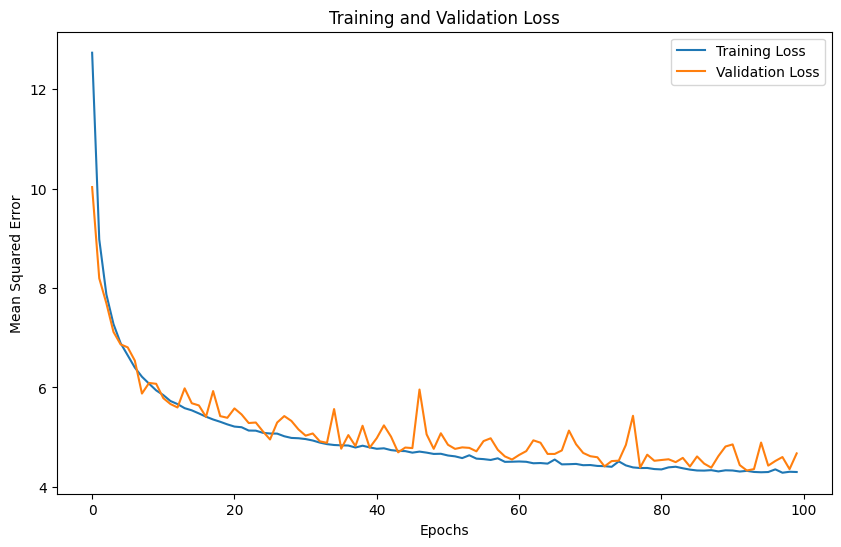

In [52]:
%%run_if $TENSORFLOW

test_loss = model.evaluate(X_test, y_test)
print(f'Test Mean Squared Error: {test_loss}')

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

### Predict

In [53]:
def predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler = None):
    input_data = np.array([[kmax, theta_i, theta_f, alpha_m, alpha_f]])
    if scaler:
        input_data = scaler.transform(input_data)

    [[th, id]] = model.predict(input_data)
    
    print(th, id)
    return (th, id)

from datetime import datetime
import time

t = datetime.now()
pred, man = predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler)
print(f"elapsed {datetime.now() - t}")
if pred is not None and man is not None:
    print(f'The angle of the middle point is: {degrees(pred)}, {pred}')
    print(f'The angle of the middle point is: {THREE_P_MAN_ID[int(man)-1]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5.119997 -1.0545716
elapsed 0:00:00.125990
The angle of the middle point is: 293.3542206254598, 5.119997024536133
The angle of the middle point is: LSLLSR


## Multi-modal Scikit-Learn

In [54]:
%%run_if $SKLEARN

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

model = MultiOutputRegressor(GradientBoostingRegressor(random_state=0))


[run_if] Skipping cell


### Train

In [55]:
%%run_if $SKLEARN
model.fit(X_train, y_train)

[run_if] Skipping cell


### Evaluate training

In [56]:
%%run_if $SKLEARN
y_val_pred = model.predict(X_val)
val_mse = root_mean_squared_error(y_val, y_val_pred)
print(f'Validation Mean Squared Error: {val_mse}')

[run_if] Skipping cell


### Predict

In [57]:
%%run_if $SKLEARN
[[th, man]] = model.predict([[1, theta_i, theta_f, alpha_m, alpha_f]])
print(th, man)

[run_if] Skipping cell
